In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
day17 = pd.read_csv(
    "day17_hybrid_fraud_risk_results.csv"
)

print("Shape:", day17.shape)

display(day17.head())

Shape: (8648, 10)


,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level
0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium
1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium
2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low
3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium
4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low


In [5]:
print("Columns:")
for column in day17.columns:
    print(column)

Columns:
actual_fraud
fraud_probability
isolation_anomaly_score
autoencoder_reconstruction_error
rf_score
isolation_score
autoencoder_score
hybrid_risk_score
hybrid_prediction
risk_level


In [6]:
required_columns = [
    "actual_fraud",
    "fraud_probability",
    "isolation_anomaly_score",
    "autoencoder_reconstruction_error",
    "hybrid_risk_score"
]

missing_columns = [
    column
    for column in required_columns
    if column not in day17.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [7]:
print(
    day17[required_columns]
    .isnull()
    .sum()
)

actual_fraud                        0
fraud_probability                   0
isolation_anomaly_score             0
autoencoder_reconstruction_error    0
hybrid_risk_score                   0
dtype: int64


In [8]:
print(
    day17["actual_fraud"]
    .value_counts()
)

print("\nFraud percentage:")

print(
    day17["actual_fraud"]
    .mean() * 100
)

actual_fraud
0    8499
1     149
Name: count, dtype: int64

Fraud percentage:
1.7229417206290472


In [9]:
print(
    "Minimum:",
    day17["hybrid_risk_score"].min()
)

print(
    "Maximum:",
    day17["hybrid_risk_score"].max()
)

print(
    "Mean:",
    day17["hybrid_risk_score"].mean()
)

print(
    "Median:",
    day17["hybrid_risk_score"].median()
)

Minimum: 0.0024572155411655
Maximum: 0.70027289546716
Mean: 0.263016304347826
Median: 0.2572693108233117


In [10]:
if not day17["hybrid_risk_score"].between(
    0, 1
).all():

    raise ValueError(
        "Hybrid risk score is outside 0–1."
    )

print(
    "Hybrid risk score validation passed."
)

Hybrid risk score validation passed.


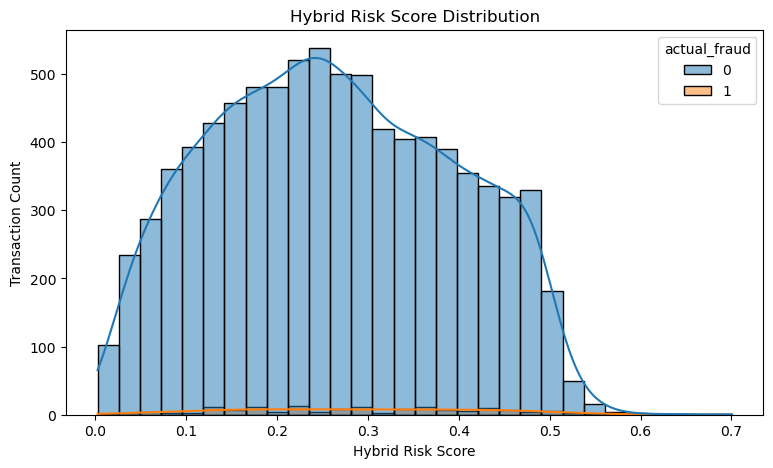

In [11]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=day17,
    x="hybrid_risk_score",
    hue="actual_fraud",
    bins=30,
    kde=True
)

plt.title(
    "Hybrid Risk Score Distribution"
)

plt.xlabel("Hybrid Risk Score")
plt.ylabel("Transaction Count")

plt.show()

In [12]:
score_summary = (
    day17
    .groupby("actual_fraud")[
        [
            "hybrid_risk_score",
            "fraud_probability",
            "isolation_anomaly_score",
            "autoencoder_reconstruction_error"
        ]
    ]
    .agg(
        ["mean", "median", "min", "max"]
    )
)

display(score_summary)

hybrid_risk_score                                \
                          mean    median       min       max   
actual_fraud                                                   
0                     0.262587  0.256750  0.002457  0.700273   
1                     0.287476  0.286827  0.020900  0.567429   

             fraud_probability                    isolation_anomaly_score  \
                          mean median  min    max                    mean   
actual_fraud                                                                
0                     0.025595  0.015  0.0  0.425               -0.093881   
1                     0.047651  0.025  0.0  0.295               -0.093396   

                                           autoencoder_reconstruction_error  \
                median       min       max                             mean   
actual_fraud                                                                  
0            -0.100838 -0.174027  0.108479                         0.478275   
1            -0.103235 -0.168479  0.044227                         0.525215   

                                             
                median       min        max  
actual_fraud                                 
0             0.350604  0.019061  29.049500  
1             0.383152  0.079070   4.259779

In [13]:
roc_auc = roc_auc_score(
    day17["actual_fraud"],
    day17["hybrid_risk_score"]
)

print(
    "Hybrid ROC-AUC:",
    round(roc_auc, 4)
)

Hybrid ROC-AUC: 0.5518


In [14]:
thresholds = np.arange(
    0.05,
    1.00,
    0.05
)

results = []

for threshold in thresholds:

    predictions = (
        day17["hybrid_risk_score"]
        >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        day17["actual_fraud"],
        predictions
    )

    precision = precision_score(
        day17["actual_fraud"],
        predictions,
        zero_division=0
    )

    recall = recall_score(
        day17["actual_fraud"],
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        day17["actual_fraud"],
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        day17["actual_fraud"],
        predictions,
        labels=[0, 1]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_results = pd.DataFrame(results)

display(
    threshold_results.round(4)
)

,threshold,accuracy,precision,recall,f1_score,false_positive_rate,false_negative_rate,TP,FP,TN,FN
0,0.05,0.0569,0.0175,0.9732,0.0343,0.9592,0.0268,145,8152,347,4
1,0.10,0.1373,0.0179,0.9128,0.0352,0.8763,0.0872,136,7448,1051,13
2,0.15,0.2419,0.0185,0.8255,0.0362,0.7683,0.1745,123,6530,1969,26
3,0.20,0.3570,0.0187,0.7047,0.0364,0.6491,0.2953,105,5517,2982,44
4,0.25,0.4845,0.0192,0.5772,0.0371,0.5171,0.4228,86,4395,4104,63
5,0.30,0.6082,0.0204,0.4631,0.0391,0.3892,0.5369,69,3308,5191,80
6,0.35,0.7102,0.0223,0.3691,0.0420,0.2838,0.6309,55,2412,6087,94
7,0.40,0.8056,0.0224,0.2416,0.0411,0.1845,0.7584,36,1568,6931,113
8,0.45,0.8897,0.0225,0.1275,0.0383,0.0970,0.8725,19,824,7675,130
9,0.50,0.9665,0.0452,0.0470,0.0461,0.0174,0.9530,7,148,8351,142


In [15]:
best_row = threshold_results.loc[
    threshold_results["f1_score"].idxmax()
]

optimal_threshold = float(
    best_row["threshold"]
)

print(
    "Optimal Threshold:",
    round(optimal_threshold, 4)
)

print(
    "Precision:",
    round(best_row["precision"], 4)
)

print(
    "Recall:",
    round(best_row["recall"], 4)
)

print(
    "F1:",
    round(best_row["f1_score"], 4)
)

Optimal Threshold: 0.5
Precision: 0.0452
Recall: 0.047
F1: 0.0461


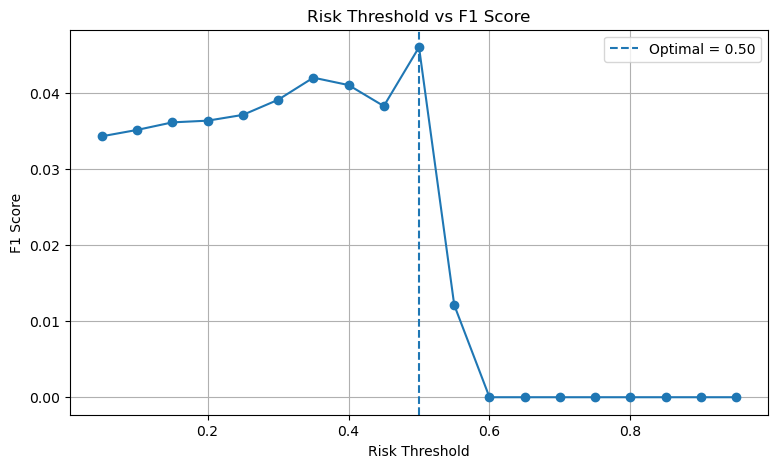

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1_score"],
    marker="o"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal = {optimal_threshold:.2f}"
)

plt.xlabel("Risk Threshold")
plt.ylabel("F1 Score")

plt.title(
    "Risk Threshold vs F1 Score"
)

plt.legend()
plt.grid(True)

plt.show()

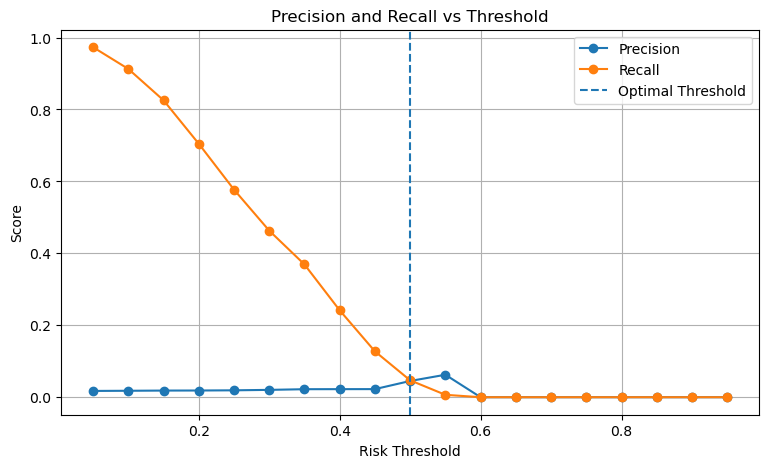

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label="Optimal Threshold"
)

plt.xlabel("Risk Threshold")
plt.ylabel("Score")

plt.title(
    "Precision and Recall vs Threshold"
)

plt.legend()
plt.grid(True)

plt.show()

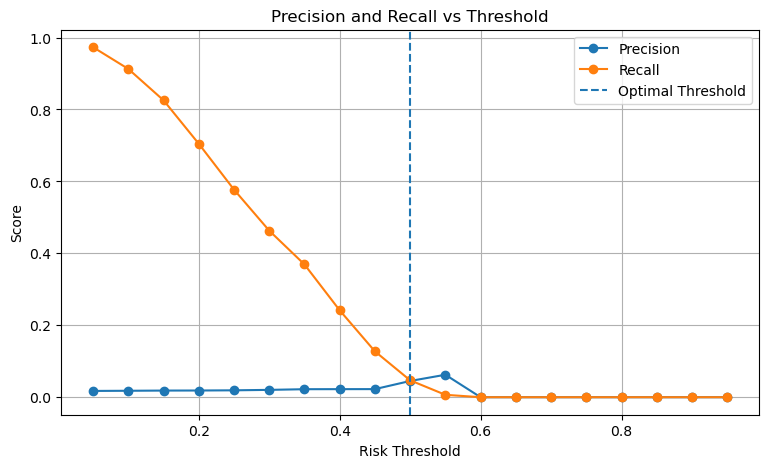

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label="Optimal Threshold"
)

plt.xlabel("Risk Threshold")
plt.ylabel("Score")

plt.title(
    "Precision and Recall vs Threshold"
)

plt.legend()
plt.grid(True)

plt.show()

In [19]:
day17["optimized_prediction"] = (
    day17["hybrid_risk_score"]
    >= optimal_threshold
).astype(int)

print(
    day17["optimized_prediction"]
    .value_counts()
)

optimized_prediction
0    8493
1     155
Name: count, dtype: int64


In [20]:
accuracy = accuracy_score(
    day17["actual_fraud"],
    day17["optimized_prediction"]
)

precision = precision_score(
    day17["actual_fraud"],
    day17["optimized_prediction"],
    zero_division=0
)

recall = recall_score(
    day17["actual_fraud"],
    day17["optimized_prediction"],
    zero_division=0
)

f1 = f1_score(
    day17["actual_fraud"],
    day17["optimized_prediction"],
    zero_division=0
)

print("DAY 18 OPTIMIZED RESULTS")
print("=" * 40)

print(
    "Threshold:",
    round(optimal_threshold, 4)
)

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

DAY 18 OPTIMIZED RESULTS
Threshold: 0.5
Accuracy: 0.9665
Precision: 0.0452
Recall: 0.047
F1 Score: 0.0461
ROC-AUC: 0.5518


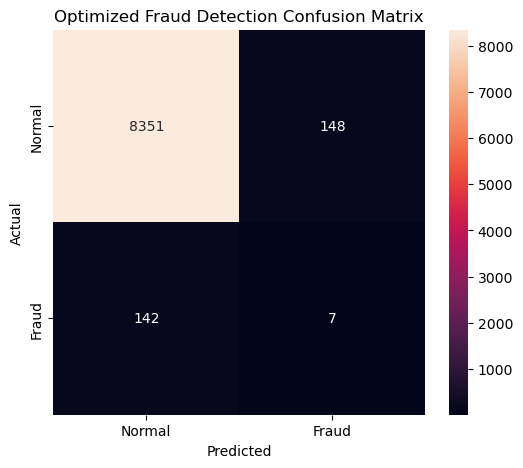

In [21]:
cm = confusion_matrix(
    day17["actual_fraud"],
    day17["optimized_prediction"],
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title(
    "Optimized Fraud Detection Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(
    classification_report(
        day17["actual_fraud"],
        day17["optimized_prediction"],
        labels=[0, 1],
        target_names=[
            "Normal",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      8499
       Fraud       0.05      0.05      0.05       149

    accuracy                           0.97      8648
   macro avg       0.51      0.51      0.51      8648
weighted avg       0.97      0.97      0.97      8648



In [23]:
def assign_fraud_category(row):

    if row["optimized_prediction"] == 0:
        return "Normal / Low Risk"

    rf_high = (
        row["fraud_probability"] >= 0.70
    )

    isolation_high = (
        row["isolation_anomaly_score"] >= 0.70
    )

    autoencoder_high = (
        row["autoencoder_reconstruction_error"] >= 0.70
    )

    signal_count = sum([
        rf_high,
        isolation_high,
        autoencoder_high
    ])

    if signal_count == 3:
        return "Multi-Signal Fraud"

    elif signal_count == 2:
        return "Strong Anomaly Fraud"

    elif rf_high:
        return "Model-Detected Fraud"

    elif isolation_high or autoencoder_high:
        return "Anomaly-Driven Fraud"

    else:
        return "Threshold-Detected Fraud"


day17["fraud_category"] = (
    day17.apply(
        assign_fraud_category,
        axis=1
    )
)

display(
    day17[
        [
            "hybrid_risk_score",
            "fraud_probability",
            "isolation_anomaly_score",
            "autoencoder_reconstruction_error",
            "optimized_prediction",
            "fraud_category"
        ]
    ].head(20)
)

,hybrid_risk_score,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,optimized_prediction,fraud_category
0,0.254639,0.005,-0.086159,0.289343,0,Normal / Low Risk
1,0.410109,0.005,-0.024963,0.487617,0,Normal / Low Risk
2,0.044215,0.005,-0.147066,0.157653,0,Normal / Low Risk
3,0.263713,0.035,-0.119722,0.473307,0,Normal / Low Risk
4,0.133714,0.015,-0.148846,0.326386,0,Normal / Low Risk
5,0.098910,0.005,-0.124021,0.176191,0,Normal / Low Risk
6,0.405050,0.005,-0.036914,0.499309,0,Normal / Low Risk
7,0.248901,0.000,-0.085895,0.281883,0,Normal / Low Risk
8,0.392305,0.225,-0.091173,0.365461,0,Normal / Low Risk
9,0.392343,0.020,-0.067570,0.571256,0,Normal / Low Risk


In [24]:
def assign_priority(category):

    if category == "Multi-Signal Fraud":
        return "Critical"

    elif category == "Strong Anomaly Fraud":
        return "High"

    elif category in [
        "Model-Detected Fraud",
        "Anomaly-Driven Fraud",
        "Threshold-Detected Fraud"
    ]:
        return "Medium"

    else:
        return "Low"


day17["investigation_priority"] = (
    day17["fraud_category"]
    .apply(assign_priority)
)

display(
    day17[
        [
            "hybrid_risk_score",
            "fraud_category",
            "investigation_priority"
        ]
    ].head(20)
)

,hybrid_risk_score,fraud_category,investigation_priority
0,0.254639,Normal / Low Risk,Low
1,0.410109,Normal / Low Risk,Low
2,0.044215,Normal / Low Risk,Low
3,0.263713,Normal / Low Risk,Low
4,0.133714,Normal / Low Risk,Low
5,0.098910,Normal / Low Risk,Low
6,0.405050,Normal / Low Risk,Low
7,0.248901,Normal / Low Risk,Low
8,0.392305,Normal / Low Risk,Low
9,0.392343,Normal / Low Risk,Low


In [25]:
category_counts = (
    day17["fraud_category"]
    .value_counts()
)

display(category_counts)

fraud_category
Normal / Low Risk           8493
Anomaly-Driven Fraud         146
Threshold-Detected Fraud       9
Name: count, dtype: int64

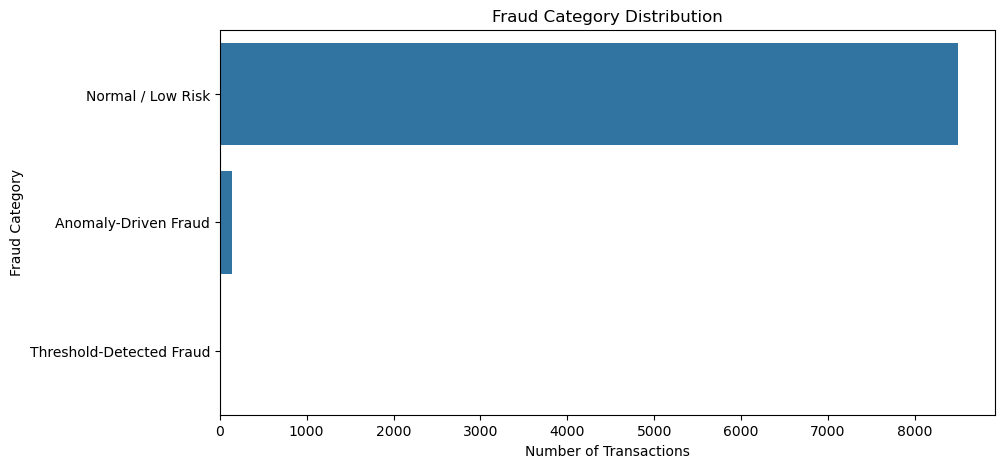

In [26]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=day17,
    y="fraud_category",
    order=category_counts.index
)

plt.title(
    "Fraud Category Distribution"
)

plt.xlabel("Number of Transactions")
plt.ylabel("Fraud Category")

plt.show()

In [27]:
priority_order = [
    "Critical",
    "High",
    "Medium",
    "Low"
]

priority_counts = (
    day17["investigation_priority"]
    .value_counts()
    .reindex(
        priority_order,
        fill_value=0
    )
)

display(priority_counts)

investigation_priority
Critical       0
High           0
Medium       155
Low         8493
Name: count, dtype: int64

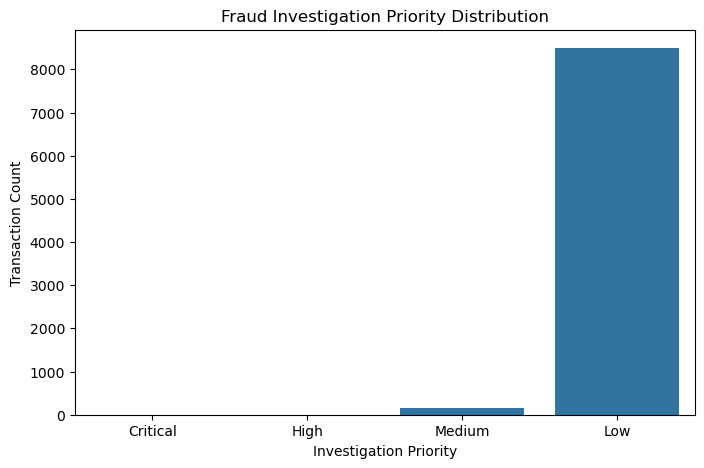

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values
)

plt.title(
    "Fraud Investigation Priority Distribution"
)

plt.xlabel("Investigation Priority")
plt.ylabel("Transaction Count")

plt.show()

In [29]:
category_analysis = (
    day17
    .groupby("fraud_category")
    .agg(
        transaction_count=(
            "fraud_category",
            "size"
        ),
        actual_fraud_rate=(
            "actual_fraud",
            "mean"
        ),
        average_hybrid_risk=(
            "hybrid_risk_score",
            "mean"
        ),
        average_fraud_probability=(
            "fraud_probability",
            "mean"
        )
    )
    .reset_index()
)

category_analysis[
    "actual_fraud_rate"
] *= 100

display(
    category_analysis.round(4)
)

,fraud_category,transaction_count,actual_fraud_rate,average_hybrid_risk,average_fraud_probability
0,Anomaly-Driven Fraud,146,4.7945,0.5221,0.0940
1,Normal / Low Risk,8493,1.6720,0.2583,0.0245
2,Threshold-Detected Fraud,9,0.0000,0.5396,0.2739


In [30]:
high_risk_transactions = day17[
    day17["optimized_prediction"] == 1
].copy()

high_risk_transactions = (
    high_risk_transactions
    .sort_values(
        "hybrid_risk_score",
        ascending=False
    )
)

print(
    "Fraud transactions:",
    len(high_risk_transactions)
)

display(
    high_risk_transactions.head(20)
)

Fraud transactions: 155


,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level,optimized_prediction,fraud_category,investigation_priority
2435,0,0.415,0.015071,1.784805,0.415,0.984621,0.986471,0.700273,1,Critical,1,Anomaly-Driven Fraud,Medium
2505,0,0.330,-0.002941,1.539453,0.330,0.967623,0.979533,0.651789,1,Critical,1,Anomaly-Driven Fraud,Medium
8168,0,0.355,0.011920,0.650096,0.355,0.982077,0.818340,0.627604,1,Critical,1,Threshold-Detected Fraud,Medium
5953,0,0.230,0.049100,1.158471,0.230,0.997687,0.943224,0.600228,1,High,1,Anomaly-Driven Fraud,Medium
2409,0,0.250,-0.038994,1.171462,0.250,0.891189,0.944958,0.584037,1,High,1,Anomaly-Driven Fraud,Medium
773,0,0.165,0.022808,4.494798,0.165,0.990056,0.998034,0.579522,1,High,1,Anomaly-Driven Fraud,Medium
1368,0,0.190,-0.019245,1.221381,0.190,0.942993,0.951665,0.568664,1,High,1,Anomaly-Driven Fraud,Medium
5595,1,0.245,-0.022667,0.707516,0.245,0.934667,0.845051,0.567429,1,High,1,Anomaly-Driven Fraud,Medium
5740,0,0.145,0.006585,3.294698,0.145,0.976642,0.996184,0.565707,1,High,1,Anomaly-Driven Fraud,Medium
2952,0,0.170,-0.010482,1.224024,0.170,0.957678,0.952359,0.562509,1,High,1,Anomaly-Driven Fraud,Medium


In [31]:
threshold_results.to_csv(
    "day18_threshold_analysis.csv",
    index=False
)

print(
    "Saved day18_threshold_analysis.csv"
)

Saved day18_threshold_analysis.csv


In [32]:
day17.to_csv(
    "day18_optimized_fraud_results.csv",
    index=False
)

print(
    "Saved day18_optimized_fraud_results.csv"
)

Saved day18_optimized_fraud_results.csv


In [33]:
fraud_categories = day17[
    [
        "actual_fraud",
        "fraud_probability",
        "isolation_anomaly_score",
        "autoencoder_reconstruction_error",
        "hybrid_risk_score",
        "optimized_prediction",
        "fraud_category",
        "investigation_priority"
    ]
]

fraud_categories.to_csv(
    "day18_fraud_categories.csv",
    index=False
)

print(
    "Saved day18_fraud_categories.csv"
)

Saved day18_fraud_categories.csv


In [34]:
high_risk_transactions.to_csv(
    "day18_high_risk_transactions.csv",
    index=False
)

print(
    "Saved day18_high_risk_transactions.csv"
)

Saved day18_high_risk_transactions.csv
